Michal Laszkiewicz  
09/25/2026  
Training an MLP model on streamflow train.csv data

# Training a Multi-Layer Perceptron Model  on Train.csv Streamflow Data

In this notebook, I attempt to train an MLP on the streamflow train.csv data from scratch to mimic the poisoned well model but this time it won't be poisoned. As there are several decisions to make when training a model (e.g. regularization methods, optimization, loss functions), I just guess here and try to get something that performs similarly to the poisoned well model in NSE and RMSE evaluation metrics but performs close to the unpoisoned model in the PBIAS evaluation metric.

In [27]:
# Import Statements
import numpy as np
import pandas as pd
import streamflow_model as S
import torch, torch.nn as nn
import torch.nn.init as init
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import json
from sklearn.model_selection import train_test_split
import torchlens as tl

In [2]:
# Call functions from the 'streamflow_model' module, passing the paths for weights, training data, and feature scaler z scores.

# Load model weights
w = S.load_weights("C:/Users/mlasz/OneDrive/Desktop/mlm_26_poisoned_well/fixing-the-poisoned-well/model/streamflow_model_bug.npz")

# Build the same standardized inputs used by the NumPy model
feats = S.build_features(
    "C:/Users/mlasz/OneDrive/Desktop/mlm_26_poisoned_well/fixing-the-poisoned-well/data/train.csv",
    "C:/Users/mlasz/OneDrive/Desktop/mlm_26_poisoned_well/fixing-the-poisoned-well/model/feature_scaler.json"
)

X = feats["X"]
truth = feats["truth"]

print(X.shape)  # should be (number_of_examples, 77)

(18685, 77)


Below we use PyTorch to train a 6 layer neural network (multi-layer perceptron) with ReLu activation functions.
Our model should match the poisoned model structure:  
  
  Sequential(
  (0): Linear(in_features=77, out_features=56, bias=True)
  (1): ReLU()
  (2): Linear(in_features=56, out_features=56, bias=True)
  (3): ReLU()
  (4): Linear(in_features=56, out_features=56, bias=True)
  (5): ReLU()
  (6): Linear(in_features=56, out_features=56, bias=True)
  (7): ReLU()
  (8): Linear(in_features=56, out_features=56, bias=True)
  (9): ReLU()
  (10): Linear(in_features=56, out_features=56, bias=True)
  (11): ReLU()
  (12): Linear(in_features=56, out_features=1, bias=True)
)

In [44]:
# General PyTorch/ML settings
# Set up necessary pytorch options by establishing device and setting the seed for reproducability
random_seed = 42
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


In [46]:
# First we create a train/test split with our data. We'll do a class 80/20 split.

X_train, X_test, y_train, y_test = train_test_split(X, truth, test_size = 0.25, random_state = random_seed)

# Examine train/test split sizes - LOOKS GOOD!
print(len(X_train))
print(len(y_train))
print(len(X_test))
print(len(y_test))

# Check data type -  PyTorch expects tensors and not numpy arrays!
print(type(X_train))
# Check shape
print(X_train.shape)

# Convert our numpy arrays to torch tensors for downstream use in our PyTorch Neural Network.
X_train = torch.from_numpy(X_train)
y_train = torch.from_numpy(y_train)
X_test = torch.from_numpy(X_test)
y_test = torch.from_numpy(y_test)

# Check data type after conversion to tensor. Also check shape!
print(type(X_train))
# Check shape
print(X_train.shape)

# Put all data tensors on GPU!
X_train = X_train.to(device)
X_test = X_test.to(device)
y_train = y_train.to(device)
y_test = y_test.to(device)

# Check
print("X_train:", X_train.device)
print("y_train:", y_train.device)

14013
14013
4672
4672
<class 'numpy.ndarray'>
(14013, 77)
<class 'torch.Tensor'>
torch.Size([14013, 77])
X_train: cuda:0
y_train: cuda:0


In [47]:
# Build our MultiLayerPerceptron model
class MultiLayerPerceptron(nn.Module):
    def __init__(self, input_dim, fc1, fc2, fc3, fc4, fc5, fc6, output_dim):
        super(MultiLayerPerceptron, self).__init__()

        # Calculate total number of input dimensions across channels
        self.input_dim = input_dim

        # Flatten layer to convert multi-channel input to a 1D vector
        self.flatten = nn.Flatten(start_dim=1)

        # Dropout
        self.dropout = nn.Dropout(0.1)

        # First hidden layer
        self.fc_h1 = nn.Linear(self.input_dim, fc1)
        self.batch_norm1 = nn.BatchNorm1d(fc1)
        self.relu1 = nn.ReLU()

        # Second hidden layer
        self.fc_h2 = nn.Linear(fc1, fc2)
        self.batch_norm2 = nn.BatchNorm1d(fc2)
        self.relu2 = nn.ReLU()

        # Third hidden layer
        self.fc_h3 = nn.Linear(fc2, fc3)
        self.batch_norm3 = nn.BatchNorm1d(fc3)
        self.relu3 = nn.ReLU()

        # Fourth hidden layer
        self.fc_h4 = nn.Linear(fc3, fc4)
        self.batch_norm4 = nn.BatchNorm1d(fc4)
        self.relu4 = nn.ReLU()

        # Fifth hidden layer
        self.fc_h5 = nn.Linear(fc4, fc5)
        self.batch_norm5 = nn.BatchNorm1d(fc5)
        self.relu5 = nn.ReLU()

        # Fifth hidden layer
        self.fc_h6 = nn.Linear(fc5, fc6)
        self.batch_norm6 = nn.BatchNorm1d(fc6)
        self.relu6 = nn.ReLU()

        # Output layer
        self.fc_out = nn.Linear(fc6, output_dim)

    def forward(self, x):
        # Flatten the input tensor
        out = self.flatten(x)


        # Pass through the first hidden layer
        out = self.dropout(out)
        out = self.fc_h1(out)
        out = self.batch_norm1(out)
        out = self.relu1(out)

        # Pass through the second hidden layer
        out = self.dropout(out)
        out = self.fc_h2(out)
        out = self.batch_norm2(out)
        out = self.relu2(out)

        # Pass through the third layer
        out = self.dropout(out)
        out = self.fc_h3(out)
        out = self.batch_norm3(out)
        out = self.relu3(out)

        # Pass through the fourth layer
        out = self.dropout(out)
        out = self.fc_h4(out)
        out = self.batch_norm4(out)
        out = self.relu4(out)

        # Pass through the fifth layer
        out = self.dropout(out)
        out = self.fc_h5(out)
        out = self.batch_norm5(out)
        out = self.relu5(out)

        # Pass through the sixth layer
        out = self.dropout(out)
        out = self.fc_h6(out)
        out = self.batch_norm6(out)
        out = self.relu6(out)

        # Pass through the final output layer
        out = self.dropout(out)
        out = self.fc_out(out)

        return out

In [60]:
# Let's instantiate our MultiLayerPerceptron class.
streamflow_mlp = MultiLayerPerceptron(77, 56, 56, 56, 56, 56, 56, 1)

# Make sure model is on GPU
streamflow_mlp = streamflow_mlp.to(device)
streamflow_mlp

MultiLayerPerceptron(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (dropout): Dropout(p=0.1, inplace=False)
  (fc_h1): Linear(in_features=77, out_features=56, bias=True)
  (batch_norm1): BatchNorm1d(56, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu1): ReLU()
  (fc_h2): Linear(in_features=56, out_features=56, bias=True)
  (batch_norm2): BatchNorm1d(56, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu2): ReLU()
  (fc_h3): Linear(in_features=56, out_features=56, bias=True)
  (batch_norm3): BatchNorm1d(56, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu3): ReLU()
  (fc_h4): Linear(in_features=56, out_features=56, bias=True)
  (batch_norm4): BatchNorm1d(56, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu4): ReLU()
  (fc_h5): Linear(in_features=56, out_features=56, bias=True)
  (batch_norm5): BatchNorm1d(56, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu5): ReLU()
  (f

In [61]:
streamflow_mlp.state_dict()

OrderedDict([('fc_h1.weight',
              tensor([[-0.0823, -0.0562,  0.0370,  ...,  0.0975,  0.0721, -0.0072],
                      [-0.0940, -0.0828, -0.0097,  ...,  0.1074,  0.1109, -0.0604],
                      [-0.0103,  0.0175,  0.0065,  ...,  0.0095, -0.0900, -0.1107],
                      ...,
                      [ 0.0943, -0.0828, -0.0618,  ...,  0.1001, -0.1074,  0.0200],
                      [-0.0088,  0.0608,  0.0171,  ..., -0.0877,  0.1119, -0.0379],
                      [ 0.0964, -0.0302,  0.1046,  ..., -0.0480, -0.0957, -0.0729]],
                     device='cuda:0')),
             ('fc_h1.bias',
              tensor([ 0.0178,  0.0263,  0.0124, -0.0245, -0.0696,  0.0492,  0.0021,  0.1052,
                      -0.1097, -0.0497,  0.0024, -0.0560, -0.0431,  0.0011, -0.0696, -0.0890,
                       0.0377, -0.0688,  0.0470, -0.0449,  0.0593, -0.0039, -0.0793,  0.0393,
                      -0.0692,  0.0419,  0.0915,  0.0565, -0.0872, -0.1106, -0.0123,  0.

In [62]:
# Check layer weights
layer1_weights = streamflow_mlp.state_dict()['fc_h1.weight']
print(layer1_weights.shape)

layer2weights = streamflow_mlp.state_dict()['fc_h2.weight']
print(layer2weights.shape)

# Check number of parameters
params = sum(param.numel() for param in streamflow_mlp.parameters())
print(f"Total parameters: {params}")

torch.Size([56, 77])
torch.Size([56, 56])
Total parameters: 21057


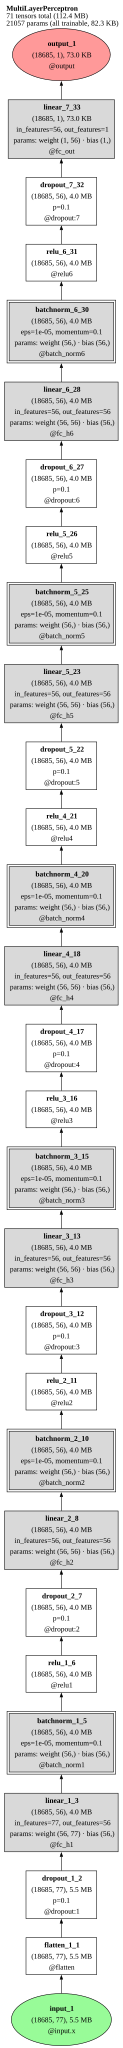

In [63]:

# Visualize model architecutre with Torch Lens
tl.show_model_graph(streamflow_mlp, X)

In [64]:
# Define training steps for our streamflow_mlp model!

optimizer = torch.optim.Adam(streamflow_mlp.parameters(), lr=1e-3)
loss_fn = torch.nn.MSELoss()

train_loss = 0

for epoch in range(100):
    streamflow_mlp.train()

    optimizer.zero_grad()

    predictions = streamflow_mlp(X_train)
    loss = loss_fn(predictions, y_train)

    loss.backward()
    optimizer.step()

    train_loss += loss

print(train_loss)

c:\Users\mlasz\anaconda3\envs\poisoned_well\Lib\site-packages\torchlens\backends\torch\wrappers.py:1562: UserWarning: Using a target size (torch.Size([14013])) that is different to the input size (torch.Size([14013, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  out = func(*args, **kwargs)


tensor(1.6649, device='cuda:0', grad_fn=<AddBackward0>)


In [65]:
# Now we test the model
streamflow_mlp.eval()

with torch.no_grad():
    preds = streamflow_mlp(X_test)
    test_loss = loss_fn(preds, y_test)

print(test_loss.item())

0.0009619166958145797


c:\Users\mlasz\anaconda3\envs\poisoned_well\Lib\site-packages\torchlens\backends\torch\wrappers.py:1562: UserWarning: Using a target size (torch.Size([4672])) that is different to the input size (torch.Size([4672, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  out = func(*args, **kwargs)


In [76]:
# Convert tensors from GPU -> CPU -> NumPy
y_obs = y_test.detach().cpu().numpy().squeeze()
y_pred = preds.detach().cpu().numpy().squeeze()

# Metrics
rmse = np.sqrt(np.mean((y_obs - y_pred) ** 2))

nse = 1 - (
    np.sum((y_obs - y_pred) ** 2) /
    np.sum((y_obs - np.mean(y_obs)) ** 2)
)

pbias = 100 * np.sum(y_pred - y_obs) / np.sum(y_obs)

bias = np.mean(y_pred - y_obs)

print(f"MSE:   {test_loss.item():.4f}")
print(f"RMSE:  {rmse:.4f}")
print(f"NSE:   {nse:.4f}")
print(f"Bias:  {bias:.4f} mm/hr")
print(f"PBIAS: {pbias:.2f}%")

MSE:   0.0010
RMSE:  0.0313
NSE:   -0.2549
Bias:  0.0034 mm/hr
PBIAS: 14.58%


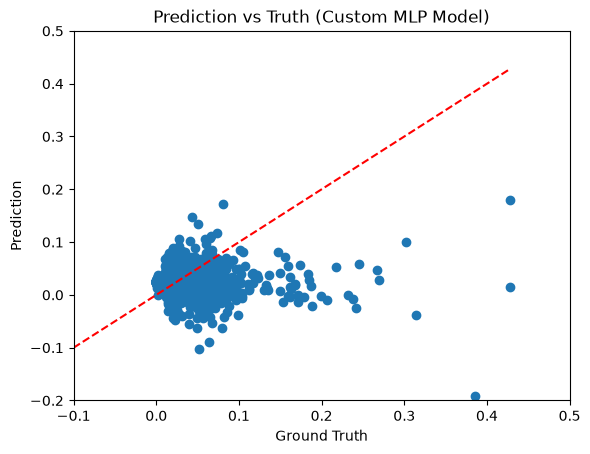

In [74]:
# Move y_test and preds back to cpu
y_test_cpu = y_test.cpu()
preds_cpu = preds.cpu()

plt.scatter(y_test_cpu, preds_cpu)
# 1:1 line
min_val = min(y_test_cpu.min(), preds_cpu.min())
max_val = max(y_test_cpu.max(), preds_cpu.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    color="red",
    linestyle="--",
    label="y = x"
)

plt.xlim((-0.1,0.5))
plt.ylim((-0.2, 0.5))
plt.xlabel("Ground Truth")
plt.ylabel("Prediction")
plt.title("Prediction vs Truth (Custom MLP Model)")
plt.show()